## Linear Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics

### Clean Data

In [3]:
weather = pd.read_csv("weatherdataCMSE.csv")

weather.head()

,STATION,NAME,DATE,AWND,PGTM,PRCP,TAVG,TMAX,TMIN,WDF2,WDF5,WSF2,WSF5,WT01,WT02,WT03,WT08
0,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-01,16.33,941.0,0.00,NaN,33.0,19.0,240.0,230.0,23.9,31.1,NaN,NaN,NaN,NaN
1,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-02,6.71,1323.0,0.00,NaN,36.0,27.0,260.0,250.0,16.1,23.0,NaN,NaN,NaN,NaN
2,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-03,6.71,1221.0,0.38,NaN,37.0,26.0,110.0,110.0,16.1,21.0,NaN,NaN,NaN,NaN
3,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-04,9.84,2304.0,0.07,NaN,38.0,21.0,300.0,290.0,23.9,33.1,NaN,NaN,NaN,NaN
4,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-05,13.20,445.0,0.00,NaN,21.0,8.0,310.0,320.0,23.0,36.9,NaN,NaN,NaN,NaN


Make all N/A values 0 to use for regression models.

In [4]:
weather = weather.fillna(0)
#len(weather[weather["WT03"] == 0])
len(weather[weather["WT03"] == 1])

38

In [5]:
thunder = weather[weather["WT03"]==1]
no_thunder = weather[weather["WT03"]==0]
no_thunder = no_thunder.sample(n=38, random_state=2)
sample_t = pd.concat([thunder, no_thunder])

Create training and testing sets with the smaller data set of thunder, using precipitation, average wind speed, and peak wind gust time.

In [6]:
labels = sample_t["WT03"]
features = sample_t.iloc[:,3:6]
features
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25)

In [7]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.508974
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       53
Method:                           MLE   Df Model:                            3
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                  0.2642
Time:                        22:38:25   Log-Likelihood:                -29.012
converged:                       True   LL-Null:                       -39.430
Covariance Type:            nonrobust   LLR p-value:                 0.0001138
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1130      1.401     -0.794      0.427      -3.860       1.634
AWND          -0.1803      0.

In [8]:
result.predict()

array([0.885323  , 0.95829835, 0.64396245, 0.0850295 , 0.3227248 ,
       0.59175518, 0.22436158, 0.75073187, 0.19686047, 0.36055228,
       0.28704077, 0.45002424, 0.28792839, 0.59242933, 0.22106719,
       0.1593171 , 0.65375928, 0.84949847, 0.31064619, 0.90865916,
       0.62474391, 0.44836103, 0.47070193, 0.99808189, 0.43311373,
       0.99162123, 0.19100465, 0.40196802, 0.11278325, 0.26796058,
       0.85003809, 0.3257091 , 0.79630091, 0.87254882, 0.06553902,
       0.102461  , 0.26457377, 0.46409505, 0.48230772, 0.30573115,
       0.30779906, 0.18075996, 0.93332827, 0.40955824, 0.98682693,
       0.41185136, 0.34773094, 0.25267752, 0.95201232, 0.92570562,
       0.11417902, 0.21051632, 0.26085841, 0.43823426, 0.32880972,
       0.40729451, 0.32224309])

In [48]:
predicted = result.predict()
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

len(y_pred)

57

In [49]:
metrics.accuracy_score(train_labels, y_pred)

0.8070175438596491

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


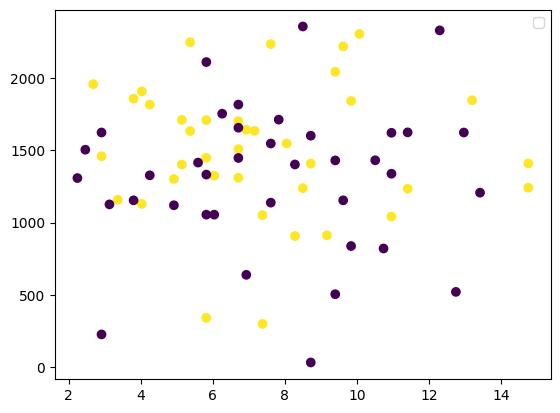

In [27]:
plt.scatter(sample_t["AWND"], sample_t["PGTM"], c=sample_t["WT03"])
plt.legend()

Same thing but remove peak wind

In [11]:
labels = sample_t["WT03"]
features = sample_t[["AWND", "PRCP"]]
features
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25, random_state=6)

In [12]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.505104
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       54
Method:                           MLE   Df Model:                            2
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                  0.2711
Time:                        22:44:19   Log-Likelihood:                -28.791
converged:                       True   LL-Null:                       -39.501
Covariance Type:            nonrobust   LLR p-value:                 2.233e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2725      0.907      1.404      0.160      -0.504       3.049
AWND          -0.2955      0.

In [13]:
predicted = result.predict()
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

len(y_pred)

57

In [14]:
metrics.accuracy_score(train_labels, y_pred)

0.7719298245614035

In [19]:
train_vectors["AWND"][train_labels==0]

1148     9.40
1544    10.74
3465     5.82
1158     7.83
521     11.41
3620    12.97
2317     2.91
3771     9.84
3003     8.28
3246     6.93
3543     6.71
551      7.61
2052     8.72
2026    10.96
1161     9.40
1682     4.25
3633     2.91
1841    13.42
1367     4.92
831     10.51
3070     6.26
3706     7.61
3740     8.72
2790     2.24
732      6.71
582      9.62
2033     8.50
1877    12.30
Name: AWND, dtype: float64

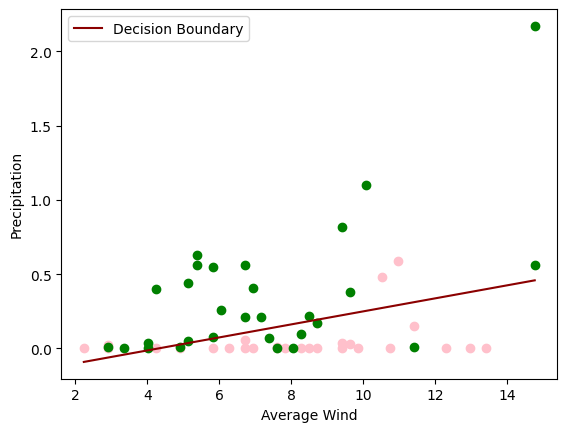

In [25]:
#coefficients

c = result.params.iloc[0]
a1 = result.params.iloc[1]
a2 = result.params.iloc[2]

#x range
x = np.linspace(train_vectors["AWND"].min(), train_vectors["AWND"].max(), 100)

#decision boundary/ classification
# c + a1(x) + a2(y) = 0
line = (-(c) - (a1*x)) / a2

#scatter plot of data in training vectors
plt.scatter(train_vectors["AWND"][train_labels==0], train_vectors["PRCP"][train_labels==0], color="pink")
plt.scatter(train_vectors["AWND"][train_labels==1], train_vectors["PRCP"][train_labels==1], color="green")
plt.xlabel("Average Wind")
plt.ylabel("Precipitation")
plt.plot(x, line, color='darkred', label="Decision Boundary")
plt.legend()

Repeat the process using min and max temperature as the predictors for thunder.

In [37]:
labels = sample_t["WT03"]
features = sample_t.iloc[:,7:9]
features
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25)

In [38]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.605756
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       54
Method:                           MLE   Df Model:                            2
Date:                Thu, 20 Nov 2025   Pseudo R-squ.:                  0.1243
Time:                        18:10:58   Log-Likelihood:                -34.528
converged:                       True   LL-Null:                       -39.430
Covariance Type:            nonrobust   LLR p-value:                  0.007429
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4988      1.515     -2.309      0.021      -6.469      -0.529
TMAX           0.0178      0.

In [60]:
predicted = result.predict()
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

len(y_pred)

57

In [61]:
metrics.accuracy_score(train_labels, y_pred)

0.7192982456140351